In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [2]:

data_directory='C:/Users/KIIT0001/Desktop/work/projects/crop_disease_detection/dataset/PlantVillage'

In [3]:
import matplotlib.pyplot as plt


In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


In [5]:
train_ds=datasets.ImageFolder(root=f'{data_directory}/train', transform=transform_train)
test_ds=datasets.ImageFolder(root=f'{data_directory}/test', transform=transform_test)
val_ds=datasets.ImageFolder(root=f'{data_directory}/val', transform=transform_test)

In [6]:
train_loader=DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader=DataLoader(test_ds, batch_size=32, shuffle=False)
val_loader=DataLoader(val_ds, batch_size=32, shuffle=False)


In [9]:
len(train_ds.classes)

15

In [8]:
import torch
import torch.nn as nn 
from torchvision import models

num_classes=len(train_ds.classes)
model=models.efficientnet_b0(weights='IMAGENET1K_V1')
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)





In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [10]:
for param in model.features.parameters():
    param.requires_grad = False

In [11]:
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.classifier.parameters(), lr=0.001)

In [12]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)
print(outputs.shape)


torch.Size([32, 15])


In [13]:
for epoch in range(5):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/5], Loss: {avg_loss:.4f}")


Epoch [1/5], Loss: 0.7502
Epoch [2/5], Loss: 0.3557
Epoch [3/5], Loss: 0.2942
Epoch [4/5], Loss: 0.2576
Epoch [5/5], Loss: 0.2392


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")


Validation Accuracy: 94.09%


In [ ]:

model_path = 'C:/Users/KIIT0001/Desktop/work/projects/crop_disease_detection/disease_detection_model.pth'
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")


Model saved to C:/Users/KIIT0001/Desktop/work/projects/crop_disease_detection/disease_detection_model.pth


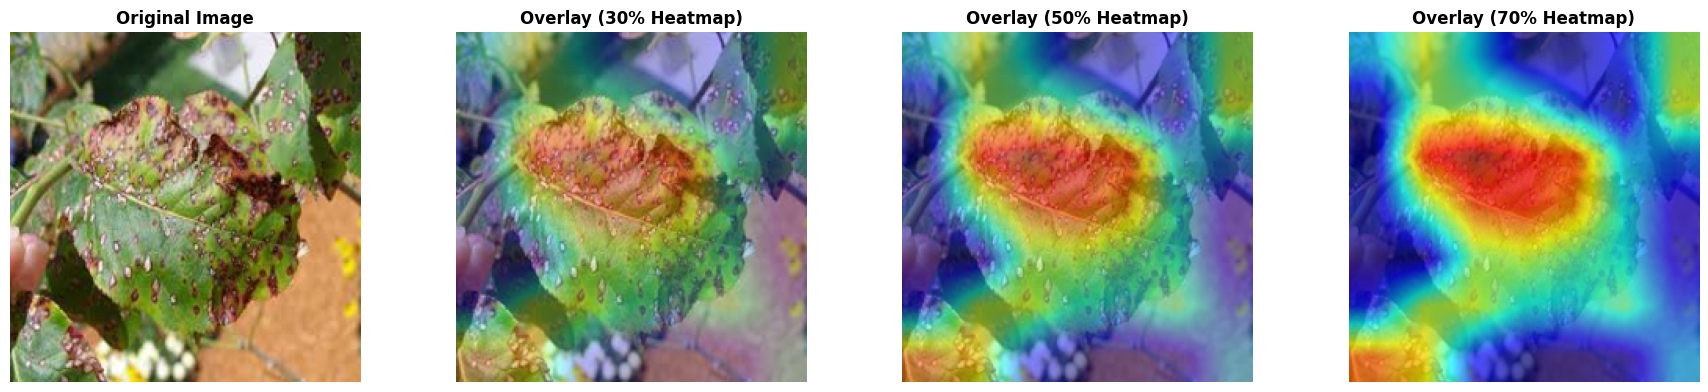

✓ Heatmap overlaid on image successfully!


: 

In [ ]:

import cv2
import numpy as np
from PIL import Image

example_image_path = 'C:/Users/KIIT0001/Desktop/work/projects/crop_disease_detection/example.jpg'

try:
    
    example_img = Image.open(example_image_path).convert('RGB')
    img_tensor = transform_test(example_img).unsqueeze(0).to(device)
    img_tensor.requires_grad_(True)

    
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        predicted_class = outputs.argmax(1).item()
    
    
    target_layer = model.features[-1]
    grad_cam = GradCAM(model, target_layer)
    cam = grad_cam.generate(img_tensor, predicted_class)
    
    
    cam_resized = cv2.resize(cam, (224, 224))
    cam_resized = (cam_resized - cam_resized.min()) / (cam_resized.max() - cam_resized.min())
    
    
    heatmap_uint8 = (cam_resized * 255).astype(np.uint8)
    heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    
    img_array = np.array(example_img.resize((224, 224)))
    
    
    overlay_30 = cv2.addWeighted(img_array, 0.7, heatmap_rgb, 0.3, 0)
    overlay_50 = cv2.addWeighted(img_array, 0.5, heatmap_rgb, 0.5, 0)
    overlay_70 = cv2.addWeighted(img_array, 0.3, heatmap_rgb, 0.7, 0)
    
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    axes[0].imshow(img_array)
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(overlay_30)
    axes[1].set_title('Overlay (30% Heatmap)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(overlay_50)
    axes[2].set_title('Overlay (50% Heatmap)', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    axes[3].imshow(overlay_70)
    axes[3].set_title('Overlay (70% Heatmap)', fontsize=12, fontweight='bold')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Heatmap overlaid on image successfully!")
    
except Exception as e:
    print(f"Error: {e}")
